Experiment 8: Deep Learning Frameworks (08_frameworks)
Aim

To study and implement deep learning models using TensorFlow and Keras frameworks.

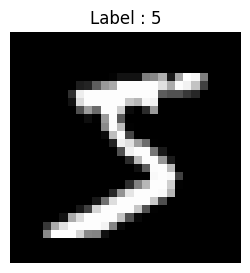

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9126 - loss: 0.2921 - val_accuracy: 0.9622 - val_loss: 0.1227
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9640 - loss: 0.1181 - val_accuracy: 0.9709 - val_loss: 0.0943
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9747 - loss: 0.0823 - val_accuracy: 0.9753 - val_loss: 0.0832
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9802 - loss: 0.0622 - val_accuracy: 0.9739 - val_loss: 0.0856
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9825 - loss: 0.0513 - val_accuracy: 0.9780 - val_loss: 0.0760
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9870 - loss: 0.0396 - val_accuracy: 0.9758 - val_loss: 0.0845
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9880 - loss: 0.0373 - val_accuracy: 0.9799 - val_loss: 0.0750
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9898 - loss: 0.0306 - val_accu

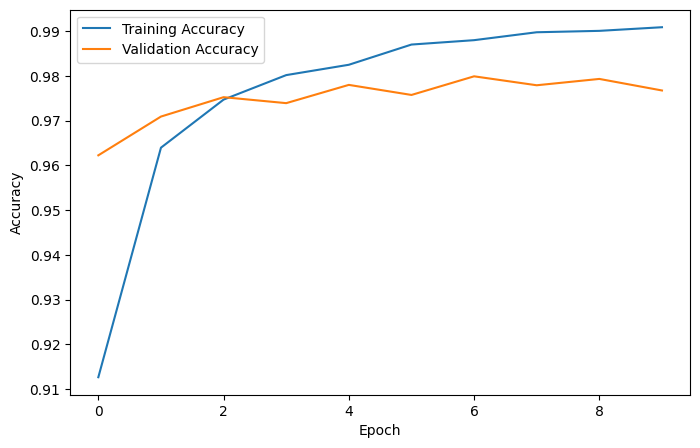

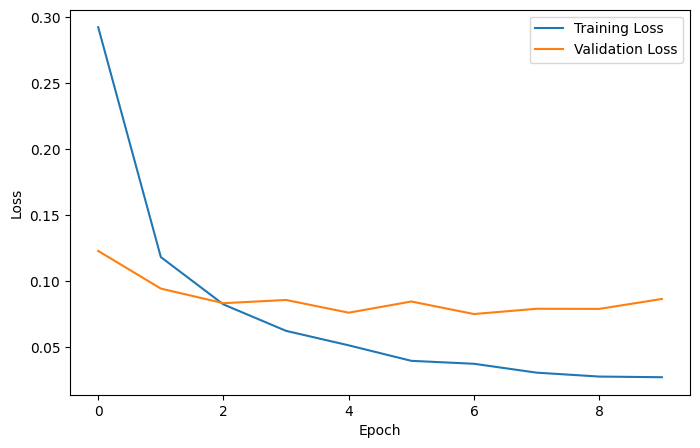

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Predicted Label : 7


In [54]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Display Sample Image
plt.figure(figsize=(3,3))
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label : {y_train[0]}")
plt.axis('off')
plt.show()

# Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape Dataset
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# One Hot Encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build Neural Network Model
model = Sequential()

# Input and Hidden Layers
model.add(Dense(
    512,
    activation='relu',
    input_shape=(784,)
))

model.add(Dropout(0.2))

model.add(Dense(
    256,
    activation='relu'
))

model.add(Dropout(0.2))

# Output Layer
model.add(Dense(
    10,
    activation='softmax'
))

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

# Plot Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Plot Loss Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Predict Sample
prediction = model.predict(X_test[:1])

predicted_label = np.argmax(prediction)

print("\nPredicted Label :", predicted_label)

Conclusion

Successfully implemented deep learning models using TensorFlow and Keras frameworks on the MNIST handwritten digit dataset